In [1]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.
import blackjax

import gpjax as gpx
from tensorflow_probability.substrates import jax as tfp
from tensorflow_probability.substrates.jax.mcmc import sample_halton_sequence

import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("../..")
from src import GP, GPBanditSampler, HaltonSequence, MMD, TVD, MCMC


/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


In [2]:
#===========================================
# Target Density
#===========================================

Srho = jnp.array([[1.0, 0.9], [0.9, 1.0]])
Srho_inv = jnp.linalg.inv(Srho)

@jax.jit
def log_density(x):
    z = jnp.array([x[0], x[1] + x[0]**2 + 1]).T
    return - ((z @ Srho_inv) @ z) / 2.0

log_density_vmap = jax.vmap(log_density)


In [3]:
#===========================================
# Excute
#===========================================

key = jrandom.key(0)
key, _key = jax.random.split(key)
bounds = ( jnp.array([-6, -20]), jnp.array([6, 2]) )
halton = HaltonSequence(dim=2, bounds=bounds, rngkey=_key)
bandit = GPBanditSampler(n_init=10, n_eval=2048, sequence=halton)

X = halton.generate(jnp.arange(10))
y = jnp.array([ jnp.sqrt(jnp.exp(log_density(x))) for x in X])

for ith in range(10, 100):
    #====== fit GP ======
    gp_mean = lambda x: 0.0
    gp_kernel = gpx.kernels.RBF(n_dims=2, lengthscale=jnp.array([1.0, 1.0]), variance=jnp.array([5.0]))
    gp = GP(gp_mean, gp_kernel)
    key, _key = jax.random.split(key)
    gp.tune_kernel_parameter(X, y, rng_key=_key)
    gp.fit(X, y)
    objective = jax.vmap(gp.jensen_square, in_axes=0, out_axes=0)
    #====================
    
    #====== fit KH ======
    X_new = bandit.find(objective)
    y_new = jnp.sqrt(jnp.exp(log_density(X_new)))
    #====================
    
    #=== Stack point ====
    X = jnp.vstack((X, X_new))
    y = jnp.hstack((y, y_new))
    #====================


  0%|          | 0/1000 [00:00<?, ?it/s]

/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

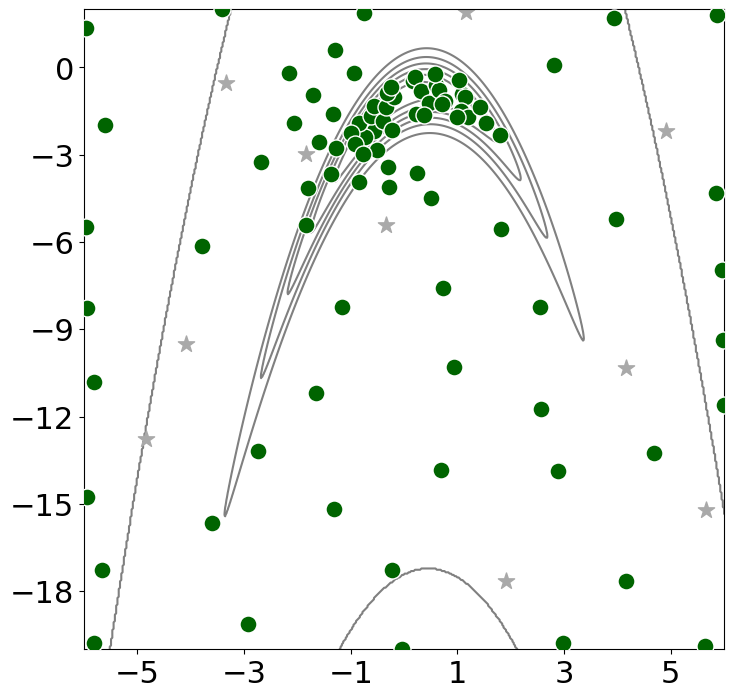

In [4]:
#===========================================
# Visualise Samples
#===========================================

def plot_sample(X, init_num=10, bounds=((-10,-10), (10,10))):
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    
    n_grids = 500
    plt_x = jnp.linspace(bounds[0][0], bounds[1][0], n_grids)
    plt_y = jnp.linspace(bounds[0][1], bounds[1][1], n_grids)
    plt_x_, plt_y_ = jnp.meshgrid(plt_x, plt_y)
    plt_z = jnp.c_[ plt_x_.flatten(), plt_y_.flatten() ]
    exp_p = jnp.exp( log_density_vmap(plt_z) ).reshape((n_grids, n_grids))
    
    ax.contour(plt_x_, plt_y_, exp_p**(1/3), levels=6, colors='gray', zorder=1)
    ax.scatter(X[:init_num,0], X[:init_num,1], label="Initial Evaluation", s=150, marker="*", color='darkgray', zorder=2)
    ax.scatter(X[init_num:,0], X[init_num:,1], label="Samples", s=150, marker="o", color='darkgreen', edgecolor="white", zorder=3)   
    ax.set_xlim(bounds[0][0], bounds[1][0])
    ax.set_ylim(bounds[0][1], bounds[1][1])
    ax.set_xticks([-5, -3, -1, 1, 3, 5])
    ax.set_yticks([0, -3, -6, -9, -12, -15, -18])
    ax.tick_params(axis='both', which='major', labelsize=22)
    
    fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

plot_sample(X, init_num=10, bounds=bounds)
